In [1]:
import importlib
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

# Ensure project root and figures_paper dir are on sys.path
_project_root = str(Path.cwd().parent) if "__file__" not in dir() else str(Path(__file__).resolve().parent.parent)
_figures_dir = str(Path.cwd()) if "__file__" not in dir() else str(Path(__file__).resolve().parent)
for _p in (_project_root, _figures_dir):
    if _p not in sys.path:
        sys.path.insert(0, _p)
warnings.filterwarnings("ignore")

# All plotting functions now live in barplots.py — import and re-export here
import barplots as _bp

importlib.reload(_bp)
from barplots import (
    # Grid / layout
    load_figure_data,
    plot_delta_model_comparison,
    plot_figure3b_nhidden,
    plot_figure5b_by_group,
    # Axis-level renderers
    plot_model_comparison,
)
from figure_config import (
    LW_THICK,
    MODEL_COLORS,
    MODEL_LABELS,
    REF_LABELS,
    configure_axis_spines,
)

print("barplots.py loaded OK")

barplots.py loaded OK


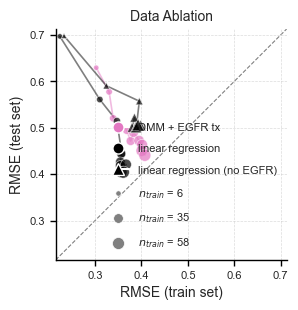

In [2]:
# Data Ablation – XY plot (train vs test RMSE, marker size = data size)
df = load_figure_data("figure6")

# (ref, context, marker) triples to plot: DMM, linear regression (with EGFR tx features),
# and linear regression without EGFR features (same color as linear regression, different marker)
series_specs = [
    ("DMM", "cytof_init", "o"),
    ("elasticnet", "cytof_init_plus_tEGFR", "o"),
    ("elasticnet", "cytof_init", "^"),
]
refs = tuple(sorted({ref for ref, _, _ in series_specs}))

# filter to just the relevant (ref, context) combinations
df = df[((df.ref == "elasticnet") & df.context.isin(["cytof_init_plus_tEGFR", "cytof_init"])) |
         (df.ref == "DMM") & (df.context == "cytof_init")]

# --- extract pct / seed, compute n_cell_lines ---
pct_mask = df.samples.str.contains("pct", na=False)

train_df = df[(df.dataset == "train") & df.ref.isin(refs) & pct_mask].copy()
val_df   = df[(df.dataset == "val")   & df.ref.isin(refs) & pct_mask].copy()

for sub in (train_df, val_df):
    sub[["pct_missing", "seed"]] = sub["samples"].str.extract(r"_(\d+)pct_(\d+)")
    sub["pct_missing"] = sub["pct_missing"].astype(int)
    sub["seed"] = sub["seed"].astype(int)
    sub["n_cell_lines"] = (sub["pct_missing"] / 100 * 58).round().astype(int)

# average RMSE per (n_cell_lines, seed, ref, context) → one point per condition
train_agg = train_df.groupby(["n_cell_lines", "seed", "ref", "context", "model"], as_index=False)["rmse"].mean()
val_agg   = val_df.groupby(["n_cell_lines", "seed", "ref", "context", "model"], as_index=False)["rmse"].mean()

merged = train_agg.merge(val_agg, on=["n_cell_lines", "seed", "ref", "context", "model"],
                         suffixes=("_train", "_test"))

# mean trajectory per (ref, context) (averaged over seeds, ordered by n_cell_lines)
mean_traj = (
    merged.groupby(["n_cell_lines", "ref", "context", 'model'], as_index=False)[["rmse_train", "rmse_test"]]
    .mean()
    .sort_values("n_cell_lines")
)

# marker sizes – scale n_cell_lines to visually distinct sizes
size_map = mean_traj["n_cell_lines"]
min_s, max_s = 15, 75
scaled_sizes = min_s + (size_map - size_map.min()) / (size_map.max() - size_map.min()) * (max_s - min_s)

# --- plot ---
fig, ax = plt.subplots(figsize=(3, 3))

color_handles = []
for ref, context, marker in series_specs:
    mask = (mean_traj["ref"] == ref) & (mean_traj["context"] == context)
    traj = mean_traj[mask]
    sizes = scaled_sizes[mask]
    if ref == "elasticnet":
        ref_name = MODEL_LABELS.get(ref)
    else:
        ref_name = MODEL_LABELS.get(traj["model"].iloc[0])  # get model name from the data

    color = MODEL_COLORS.get(ref_name)
    label = REF_LABELS.get(ref_name, ref_name)
    if ref == "elasticnet" and context == "cytof_init":
        label = f"{label} (no EGFR)"

    # connecting line
    ax.plot(traj["rmse_train"], traj["rmse_test"],
            color=color, lw=1.2, alpha=0.5, zorder=1)

    # scatter (mean per n_cell_lines)
    ax.scatter(traj["rmse_train"], traj["rmse_test"],
               s=sizes, alpha=0.7, color=color, edgecolors="white",
               linewidths=0.5, marker=marker, zorder=2)

    color_handles.append(
        plt.Line2D([0], [0], marker=marker, color='w',
                   markerfacecolor=color, markersize=8, label=label)
    )

# diagonal reference line
lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], ls="--", color="grey", lw=0.8, zorder=0)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")

ax.set_xlabel("RMSE (train set)")
ax.set_ylabel("RMSE (test set)")
ax.set_title("Data Ablation")
configure_axis_spines(ax)
ax.grid(False, which="both", ls="--", lw=0.5, alpha=0.7)

# size handles
unique_ncl = sorted(mean_traj["n_cell_lines"].unique())
legend_ncl = [unique_ncl[0], unique_ncl[len(unique_ncl)//2], unique_ncl[-1]]
size_handles = [
    ax.scatter([], [], s=min_s + (n - size_map.min()) / (size_map.max() - size_map.min()) * (max_s - min_s),
               color="grey", edgecolors="white", linewidths=0.5, label=f"$n_{{train}}$ = {n}")
    for n in legend_ncl
]

# single combined legend inside lower right
ax.legend(handles=color_handles + size_handles,
          loc="lower right", frameon=False, labelspacing=1.0)

fig.savefig("DataAblation.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

,context,model_label,p_raw,p_adjusted,significant,delta_rmse_mean,delta_rmse_std,delta_rmse_median
0,CyTOF,DMM + EGFR tx + all growth factors,0.998047,0.998047,False,0.025519,0.027185,0.015262
1,CyTOF,DMM + EGFR tx + BTC,0.981445,0.998047,False,0.008106,0.012423,0.011423
2,CyTOF,DMM + EGFR tx + EREG,0.998047,0.998047,False,0.033716,0.025550,0.036880
3,CyTOF,DMM + EGFR tx + NRG1,0.539062,0.998047,False,0.002730,0.030762,-0.000595
4,CyTOF,DMM + EGFR tx + NRG2,0.967773,0.998047,False,0.012157,0.018347,0.009774
5,CyTOF,DMM + EGFR tx + TGFA,0.967773,0.998047,False,0.011668,0.016653,0.012975


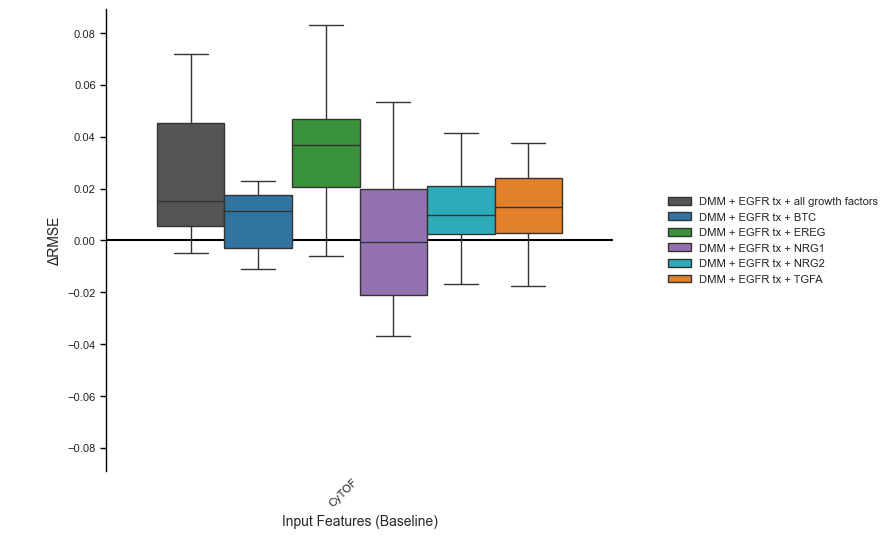

In [6]:
# Figure 4 – Growth Factors (tBTC, tEREG, tNRG1, tNRG2, tTGFA)
_, _, stats =plot_delta_model_comparison(
    load_figure_data("figure4"),
    refs=("DMM",),
    dataset="test",
    models=[
        "EGFR_MAPK__logobs_tegfr_aggavg",
        "EGFR_MAPK__logobs_tegfr_ttgfa_tbtc_tereg_tnrg1_tnrg2_aggavg",
        "EGFR_MAPK__logobs_tegfr_tbtc_aggavg",
        "EGFR_MAPK__logobs_tegfr_tereg_aggavg",
        "EGFR_MAPK__logobs_tegfr_tnrg1_aggavg",
        "EGFR_MAPK__logobs_tegfr_tnrg2_aggavg",
        "EGFR_MAPK__logobs_tegfr_ttgfa_aggavg",
    ],
    baseline_model="EGFR_MAPK__logobs_tegfr_aggavg",
    save_path="GrowthFactorComparison.png",
);
stats

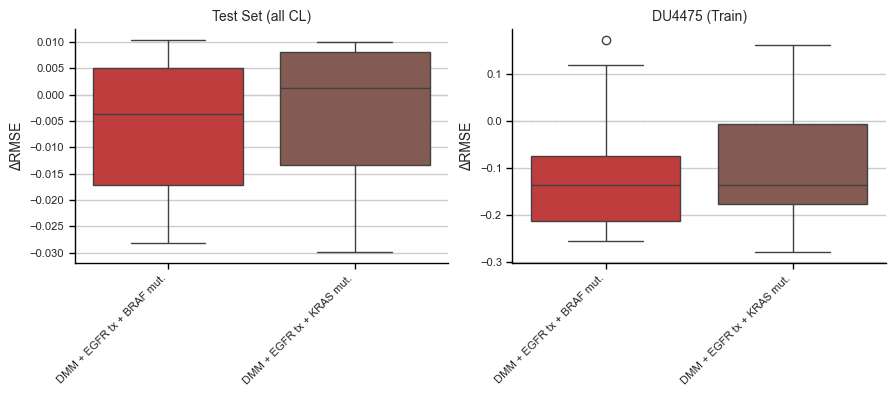

In [9]:
# Mutation analysis – test set (all CL) vs DU4475 training set, side-by-side
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, false_discovery_control
from common import basedir

MUTATION_MODELS = [
    "EGFR_MAPK__logobs_tegfr_aggavg",
    "EGFR_MAPK__logobs_tegfr_mbraf_aggavg",
    "EGFR_MAPK__logobs_tegfr_mkras_aggavg",
]
BASELINE = "EGFR_MAPK__logobs_tegfr_aggavg"
NON_BASELINE = [m for m in MUTATION_MODELS if m != BASELINE]

def _compute_delta(pivot, non_baseline, baseline):
    rows = []
    for m in non_baseline:
        if m not in pivot.columns:
            continue
        for d in (pivot[m] - pivot[baseline]).dropna():
            rows.append({"model_label": MODEL_LABELS.get(m, m), "delta_rmse": d})
    return pd.DataFrame(rows)

def _annotate_sig(ax, delta_df, labels):
    raw = [
        wilcoxon(delta_df[delta_df.model_label == lbl]["delta_rmse"].values,
                 alternative="less")[1]
        if len(delta_df[delta_df.model_label == lbl]) > 1 else 1.0
        for lbl in labels
    ]
    adj = false_discovery_control(raw, method="bh")
    for i, (lbl, adj_p) in enumerate(zip(labels, adj)):
        stars = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
        if not stars:
            continue
        data = delta_df[delta_df.model_label == lbl]["delta_rmse"]
        q3, q1 = data.quantile(0.75), data.quantile(0.25)
        whisker = min(data.max(), q3 + 1.5 * (q3 - q1))
        ax.text(i, whisker + 0.005, stars, ha="center", va="bottom",
                fontsize=FONTSIZE, fontweight="bold", color="green")

# ── Test set: aggregate delta-RMSE ───────────────────────────────────
df_agg = load_figure_data("figure4")
test_df = df_agg[
    (df_agg.dataset == "val") &
    df_agg.samples.str.startswith("all") &
    (df_agg.ref == "DMM")
].copy()
test_pivot = test_df.pivot_table(index="job", columns="model", values="rmse", aggfunc="mean")
delta_test = _compute_delta(test_pivot, NON_BASELINE, BASELINE)

# ── DU4475 train: per-cell-line delta-RMSE ───────────────────────────
dfs = []
for m in MUTATION_MODELS:
    fp = basedir / f"eval/{m}/dream_cytof/by_cl_cond_obs_figure4.csv"
    dfs.append(pd.read_csv(fp, index_col=0).assign(model=m))
df_cl = pd.concat(dfs)

du = df_cl[
    (df_cl["sample"] == "cDU4475") &
    (df_cl.dataset == "train") &
    (df_cl.ref == "DMM") &
    (df_cl.samples == "all") &
    (df_cl.observable == "pERK_Y204_obs") &
    (df_cl.condition == "iMEK")
]
du_agg = du.groupby(["model", "job"])["rmse"].mean().reset_index()
du_pivot = du_agg.pivot_table(index="job", columns="model", values="rmse")
delta_du = _compute_delta(du_pivot, NON_BASELINE, BASELINE)

# ── Plot ──────────────────────────────────────────────────────────────
non_bl_labels = [MODEL_LABELS.get(m, m) for m in NON_BASELINE]
palette = {MODEL_LABELS.get(m, m): MODEL_COLORS.get(MODEL_LABELS.get(m, m), "#333333")
           for m in NON_BASELINE}

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, delta_df, title in zip(
    axes,
    [delta_test, delta_du],
    ["Test Set (all CL)", "DU4475 (Train)"],
):
    sns.boxplot(
        data=delta_df, x="model_label", y="delta_rmse",
        order=non_bl_labels, palette=palette,
        hue="model_label", legend=False, ax=ax,
    )
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, zorder=0)
    ax.set_xlabel("")
    ax.set_ylabel("ΔRMSE")
    ax.set_title(title)
    configure_axis_spines(ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    _annotate_sig(ax, delta_df, non_bl_labels)

fig.tight_layout()
plt.show()

In [10]:
delta_du.delta_rmse.mean()

np.float64(-0.10004475641646252)


=== RMSE-correlated ===


,marker,augmentation_type,p_raw,p_adjusted,significant,delta_rmse_mean,delta_rmse_std,delta_rmse_median
3,FLJ45252,protein,0.032227,0.290039,False,-0.014245,0.020538,-0.017151
7,SUMO1,protein,0.065430,0.294434,False,-0.008824,0.018396,-0.018018
1,DOC2A,transcript,0.278320,0.417480,False,-0.004289,0.027125,-0.011776
4,GSN,protein,0.278320,0.417480,False,-0.000674,0.034254,-0.017147
5,HTATIP2,protein,0.215820,0.417480,False,-0.000023,0.018541,-0.006709
6,STXBP2,protein,0.161133,0.417480,False,-0.008723,0.028488,-0.014808
2,PRKAA2,transcript,0.577148,0.742048,False,-0.000767,0.024603,0.002306
0,ALKBH3,transcript,0.812500,0.883789,False,0.023866,0.048613,0.003934
8,TAGLN2,protein,0.883789,0.883789,False,0.013814,0.029207,0.006216



=== Parameter deviations ===


,marker,augmentation_type,p_raw,p_adjusted,significant,delta_rmse_mean,delta_rmse_std,delta_rmse_median
2,NCDN,transcript,0.041992,0.293945,False,-0.016299,0.023977,-0.022263
6,SEZ6L2,protein,0.096680,0.338379,False,-0.007855,0.018038,-0.009647
0,ANKRD50,transcript,0.278320,0.389648,False,-0.004197,0.026660,-0.003423
1,MAP3K8,transcript,0.187500,0.389648,False,-0.003070,0.018884,-0.007558
5,PLS1,protein,0.246094,0.389648,False,-0.007068,0.024984,-0.015126
3,STX7,transcript,0.500000,0.583333,False,-0.001908,0.027044,-0.013551
4,NCDN,protein,0.615234,0.615234,False,0.003604,0.023317,-0.000492


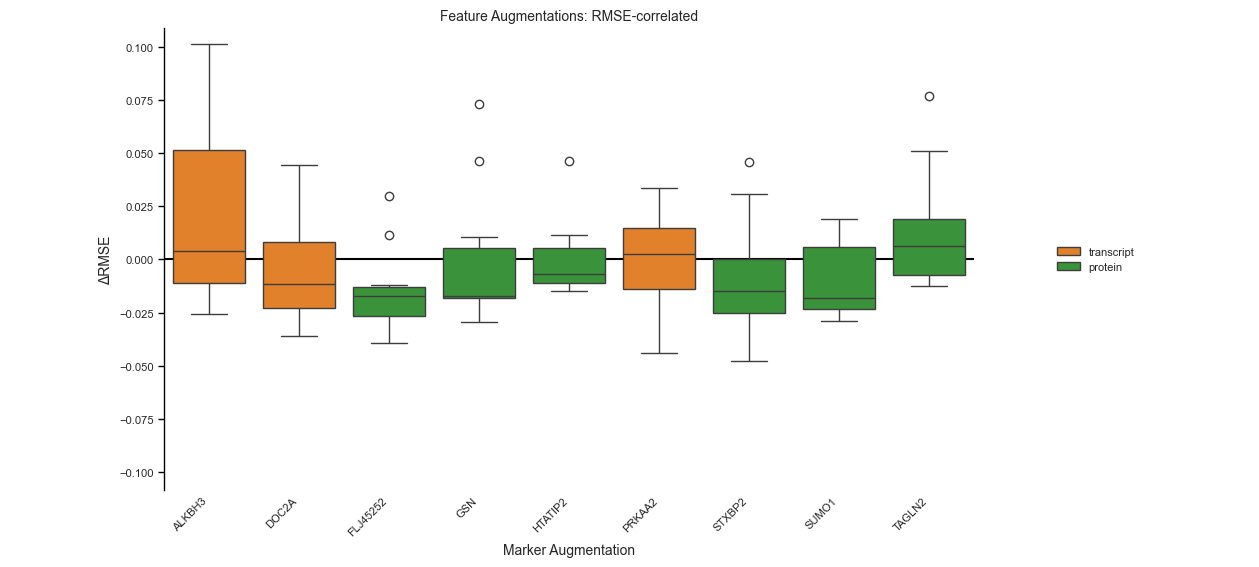

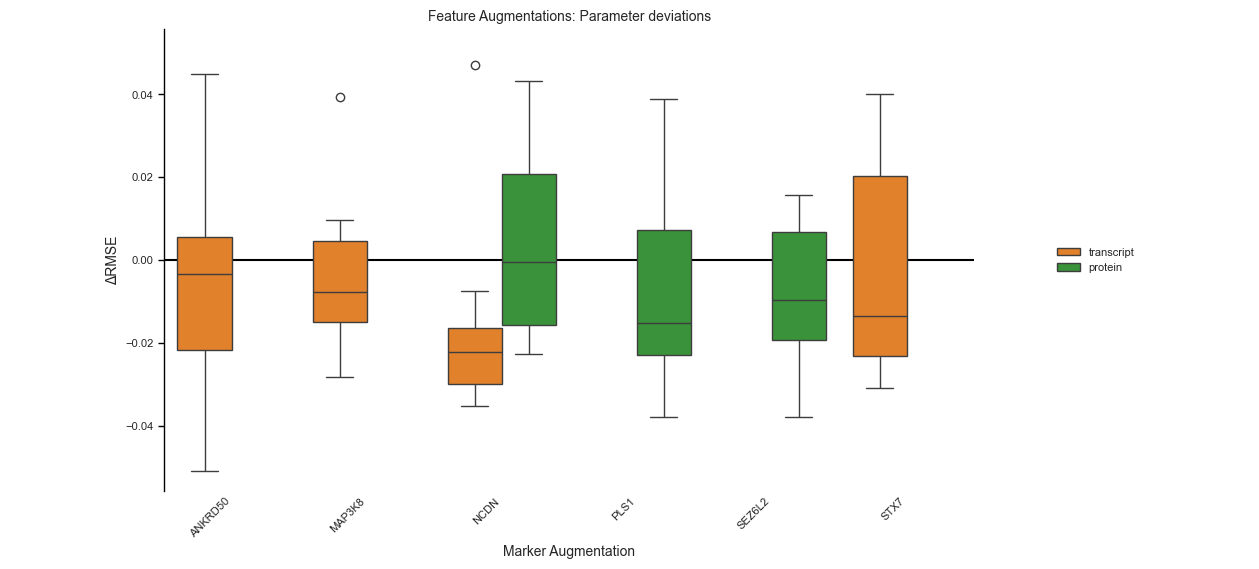

In [12]:
# Figure 5b – Feature Augmentations: one plot per gene group with per-group FDR
group_results = plot_figure5b_by_group(
    figsize_per_group=(16, 6),
    save_path_template="FeatureAugmentation_{group}.png",
)
for group_name, (fig, ax, stats_df) in group_results.items():
    print(f"\n=== {group_name} ===")
    if stats_df is not None:
        display(stats_df)

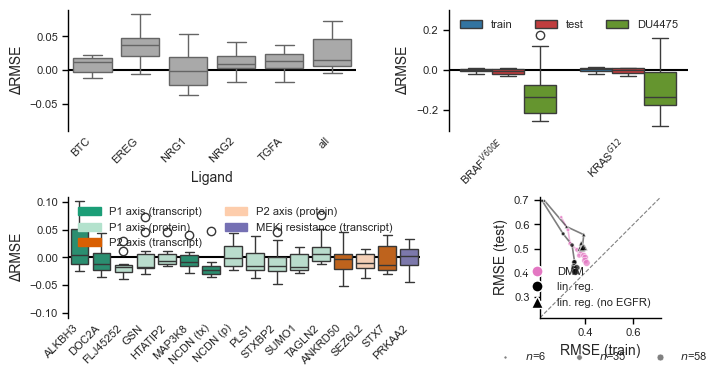

In [16]:
# ─── Composite Figure: Ligand | Mutation (Train/Test/DU4475) | Augmentation | Data Ablation ───
import importlib

import barplots as _bp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

importlib.reload(_bp)
import figure_config
from barplots import (
    load_figure_data,
)

importlib.reload(figure_config)
from figure_config import (
    FONTSIZE,
    MODEL_COLORS,
    MODEL_LABELS,
    apply_figure_style,
    configure_axis_spines,
)

from common import basedir

apply_figure_style()

# ── Model lists ──────────────────────────────────────────────────────────────
_GF_MODELS = [
    "EGFR_MAPK__logobs_tegfr_aggavg",
    "EGFR_MAPK__logobs_tegfr_ttgfa_tbtc_tereg_tnrg1_tnrg2_aggavg",
    "EGFR_MAPK__logobs_tegfr_tbtc_aggavg",
    "EGFR_MAPK__logobs_tegfr_tereg_aggavg",
    "EGFR_MAPK__logobs_tegfr_tnrg1_aggavg",
    "EGFR_MAPK__logobs_tegfr_tnrg2_aggavg",
    "EGFR_MAPK__logobs_tegfr_ttgfa_aggavg",
]
_MUT_MODELS = [
    "EGFR_MAPK__logobs_tegfr_aggavg",
    "EGFR_MAPK__logobs_tegfr_mbraf_aggavg",
    "EGFR_MAPK__logobs_tegfr_mkras_aggavg",
]
_MUT_BASELINE = "EGFR_MAPK__logobs_tegfr_aggavg"
_MUT_NON_BL   = [m for m in _MUT_MODELS if m != _MUT_BASELINE]

# ── Process → tab20 pair indices (dark=transcript, light=protein) ─────────────
_PROCESS_MAP = {
    "SEZ6L2":   "P2 axis",
    "STX7":     "P2 axis",
    "ANKRD50":  "P2 axis",
    "ALKBH3":   "P1 axis",
    "DOC2A":    "P1 axis",
    "FLJ45252": "P1 axis",
    "GSN":      "P1 axis",
    "HTATIP2":  "P1 axis",
    "STXBP2":   "P1 axis",
    "SUMO1":    "P1 axis",
    "TAGLN2":   "P1 axis",
    "NCDN":     "P1 axis",
    "PLS1":     "P1 axis",
    "MAP3K8":   "P1 axis",
    "PRKAA2":   "MEKi resistance",
}
_PROCESS_ORDER = ["P1 axis", "P2 axis", "MEKi resistance"]
_PROC_COLORS = {
    "P1 axis": (sns.color_palette("Dark2")[0], sns.color_palette("Pastel2")[0]),
    "MEKi resistance": (sns.color_palette("Dark2")[2], sns.color_palette("Pastel2")[2]),
    "P2 axis": (sns.color_palette("Dark2")[1], sns.color_palette("Pastel2")[1])
}

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 4))
_gs_outer = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.55)
_gs_top   = _gs_outer[0].subgridspec(1, 2, width_ratios=[1.2, 1], wspace=0.35)
_gs_bot   = _gs_outer[1].subgridspec(1, 2, width_ratios=[2, 1], wspace=0.35)

ax_A = fig.add_subplot(_gs_top[0, 0])
ax_B = fig.add_subplot(_gs_top[0, 1])
ax_C = fig.add_subplot(_gs_bot[0, 0])
ax_D = fig.add_subplot(_gs_bot[0, 1])

# ─── A: Ligand Integration – x-axis = ligand, single colour ─────────────────
_GF_LABELS = {
    "EGFR_MAPK__logobs_tegfr_tbtc_aggavg":                          "BTC",
    "EGFR_MAPK__logobs_tegfr_tereg_aggavg":                         "EREG",
    "EGFR_MAPK__logobs_tegfr_tnrg1_aggavg":                         "NRG1",
    "EGFR_MAPK__logobs_tegfr_tnrg2_aggavg":                         "NRG2",
    "EGFR_MAPK__logobs_tegfr_ttgfa_aggavg":                         "TGFA",
    "EGFR_MAPK__logobs_tegfr_ttgfa_tbtc_tereg_tnrg1_tnrg2_aggavg": "all",
}
_GF_ORDER  = ["BTC", "EREG", "NRG1", "NRG2", "TGFA", "all"]
_GF_NON_BL = [m for m in _GF_MODELS if m != _MUT_BASELINE]

_df4 = load_figure_data("figure4")
_gf_test  = _df4[(_df4.dataset == "val") & _df4.samples.str.startswith("all") & (_df4.ref == "DMM")]
_gf_pivot = _gf_test.pivot_table(index="job", columns="model", values="rmse", aggfunc="mean")
_gf_rows  = []
for _m in _GF_NON_BL:
    if _m not in _gf_pivot.columns or _MUT_BASELINE not in _gf_pivot.columns:
        continue
    _lbl = _GF_LABELS.get(_m, _m)
    for _d in (_gf_pivot[_m] - _gf_pivot[_MUT_BASELINE]).dropna():
        _gf_rows.append({"ligand": _lbl, "delta_rmse": _d})
_gf_df = pd.DataFrame(_gf_rows)

sns.boxplot(data=_gf_df, x="ligand", y="delta_rmse",
            order=_GF_ORDER, color="#A9A9A9", ax=ax_A)
ax_A.axhline(0, color="black", linestyle="-", linewidth=LW_THICK, alpha=1.0, zorder=0)
ax_A.set_xlabel("Ligand")
ax_A.set_ylabel("ΔRMSE")
ax_A.set_xticklabels(ax_A.get_xticklabels(), rotation=45, ha="right")
configure_axis_spines(ax_A)
_yabs_A = max(abs(v) for v in ax_A.get_ylim())
ax_A.set_ylim(-_yabs_A, _yabs_A)
ax_A.spines["bottom"].set_visible(False)
ax_A.tick_params(axis="x", which="both", length=0)
ax_A.grid(False, axis="y")

# ─── B: Mutation Integration – Train / Test / DU4475 grouped boxplot ──────────
_MUT_LABELS = {
    "EGFR_MAPK__logobs_tegfr_mbraf_aggavg": r"BRAF$^{V600E}$",
    "EGFR_MAPK__logobs_tegfr_mkras_aggavg": r"KRAS$^{G12}$",
}

def _delta_df(pivot, non_bl, bl, label_map=None):
    rows = []
    for m in non_bl:
        if m not in pivot.columns:
            continue
        lbl = label_map.get(m, MODEL_LABELS.get(m, m)) if label_map else MODEL_LABELS.get(m, m)
        for d in (pivot[m] - pivot[bl]).dropna():
            rows.append({"model_label": lbl, "delta_rmse": d})
    return pd.DataFrame(rows)

_test_df = _df4[
    (_df4.dataset == "val") & _df4.samples.str.startswith("all") & (_df4.ref == "DMM")
]
_delta_test = _delta_df(
    _test_df.pivot_table(index="job", columns="model", values="rmse", aggfunc="mean"),
    _MUT_NON_BL, _MUT_BASELINE, _MUT_LABELS,
).assign(split="test")

_train_df = _df4[(_df4.dataset == "train") & (_df4.ref == "DMM")]
_delta_train = _delta_df(
    _train_df.pivot_table(index="job", columns="model", values="rmse", aggfunc="mean"),
    _MUT_NON_BL, _MUT_BASELINE, _MUT_LABELS,
).assign(split="train")

_dfs_cl = []
for _m in _MUT_MODELS:
    _fp = basedir / f"eval/{_m}/dream_cytof/by_cl_cond_obs_figure4.csv"
    _dfs_cl.append(pd.read_csv(_fp, index_col=0).assign(model=_m))
_df_cl = pd.concat(_dfs_cl)
_du = _df_cl[
    (_df_cl["sample"] == "cDU4475") & (_df_cl.dataset == "train") &
    (_df_cl.ref == "DMM") & (_df_cl.samples == "all") &
    (_df_cl.observable == "pERK_Y204_obs") & (_df_cl.condition == "iMEK")
]
_du_pivot = (
    _du.groupby(["model", "job"])["rmse"].mean().reset_index()
    .pivot_table(index="job", columns="model", values="rmse")
)
_delta_du = _delta_df(_du_pivot, _MUT_NON_BL, _MUT_BASELINE, _MUT_LABELS).assign(split="DU4475")

_combined      = pd.concat([_delta_train, _delta_test, _delta_du], ignore_index=True)
_non_bl_labels = [_MUT_LABELS.get(m, MODEL_LABELS.get(m, m)) for m in _MUT_NON_BL]
_split_order   = ["train", "test", "DU4475"]
_split_pal     = {"train": "#1f77b4", "test": "#d62728", "DU4475": sns.color_palette("Dark2")[4]}

sns.boxplot(
    data=_combined, x="model_label", y="delta_rmse",
    hue="split", hue_order=_split_order,
    order=_non_bl_labels, palette=_split_pal, ax=ax_B,
)
ax_B.axhline(0, color="black", linestyle="-", linewidth=LW_THICK, alpha=1.0, zorder=0)
ax_B.set_xlabel("")
ax_B.set_ylabel("ΔRMSE")
ax_B.set_xticklabels(ax_B.get_xticklabels(), rotation=45, ha="right")
configure_axis_spines(ax_B)
ax_B.legend(title="", fontsize=FONTSIZE, frameon=False, ncol=3)
_yabs_B = max(abs(v) for v in ax_B.get_ylim())
ax_B.set_ylim(-_yabs_B, _yabs_B)
ax_B.spines["bottom"].set_visible(False)
ax_B.tick_params(axis="x", which="both", length=0)
ax_B.grid(False, axis="y")

_n_hue       = len(_split_order)
_dodge_w     = 0.8
_box_offsets = [(j - (_n_hue - 1) / 2) * _dodge_w / _n_hue for j in range(_n_hue)]
for _si, (_sname, _sdelta) in enumerate(
    zip(_split_order, [_delta_train, _delta_test, _delta_du])
):
    _raw_p = [
        wilcoxon(_sdelta[_sdelta.model_label == _lbl]["delta_rmse"].values, alternative="less")[1]
        if len(_sdelta[_sdelta.model_label == _lbl]) > 1 else 1.0
        for _lbl in _non_bl_labels
    ]
    _adj_p = false_discovery_control(_raw_p, method="bh")
    for _mi, (_lbl, _ap) in enumerate(zip(_non_bl_labels, _adj_p)):
        _stars = "***" if _ap < 0.001 else "**" if _ap < 0.01 else "*" if _ap < 0.05 else ""
        if not _stars:
            continue
        _data = _sdelta[_sdelta.model_label == _lbl]["delta_rmse"]
        _q3, _q1 = _data.quantile(0.75), _data.quantile(0.25)
        _whisker = min(_data.max(), _q3 + 1.5 * (_q3 - _q1))
        ax_B.text(_mi + _box_offsets[_si], _whisker + 0.005, _stars,
                  ha="center", va="bottom", fontsize=FONTSIZE, fontweight="bold", color="green")

# ─── C: Feature Augmentation – by process, transcript vs protein distinguished
_dmm_5b, _ref_5b = _bp._prepare_figure5b_data()

_proc_df = _dmm_5b[_dmm_5b.marker.isin(_PROCESS_MAP)].copy()
_proc_df["process"] = _proc_df["marker"].map(_PROCESS_MAP)

# Markers present in data, ordered by (process, marker)
_markers_present = sorted(
    _proc_df.marker.unique(),
    key=lambda m: (_PROCESS_ORDER.index(_PROCESS_MAP[m]), m),
)
# Markers with both transcript and protein → get "(tx)" / "(p)" suffixes
_multi_mod = {
    m for m in _markers_present
    if _proc_df[_proc_df.marker == m]["augmentation_type"].nunique() > 1
}

# Build ordered x-label list and (x_label → color) palette
_x_to_mat = {}  # x_label → (marker, aug_type)
for _m in _markers_present:
    for _at in ["transcript", "protein"]:
        if len(_proc_df[(_proc_df.marker == _m) & (_proc_df.augmentation_type == _at)]) == 0:
            continue
        if _m in _multi_mod:
            _xl = f"{_m} (tx)" if _at == "transcript" else f"{_m} (p)"
        else:
            _xl = _m
        _x_to_mat[_xl] = (_m, _at)

_x_order_c = list(_x_to_mat.keys())

_x_palette = {}
for _xl, (_m, _at) in _x_to_mat.items():
    _proc = _PROCESS_MAP[_m]
    _dark, _light = _PROC_COLORS[_proc]  # dark and light colors for transcript and protein
    _x_palette[_xl] = _dark if _at == "transcript" else _light

_proc_df["x_label"] = _proc_df.apply(
    lambda r: (f"{r['marker']} (tx)" if r["augmentation_type"] == "transcript"
               else f"{r['marker']} (p)")
    if r["marker"] in _multi_mod else r["marker"],
    axis=1,
)

sns.boxplot(
    data=_proc_df, x="x_label", y="delta_rmse",
    order=_x_order_c, palette=_x_palette,
    hue="x_label", legend=False,
    ax=ax_C,
)
ax_C.axhline(0, color="black", linestyle="-", linewidth=LW_THICK, alpha=1.0, zorder=0)
ax_C.set_xlabel("")
ax_C.set_ylabel("ΔRMSE")
ax_C.set_xticklabels(ax_C.get_xticklabels(), rotation=45, ha="right")
configure_axis_spines(ax_C)
_yabs_C = max(abs(v) for v in ax_C.get_ylim())
ax_C.set_ylim(-_yabs_C, _yabs_C)
ax_C.spines["bottom"].set_visible(False)
ax_C.tick_params(axis="x", which="both", length=0)
ax_C.grid(False, axis="y")

# Legend: one entry per (process, modality) combination present
_c_legend = []
for _proc in _PROCESS_ORDER:
    if _proc not in _proc_df["process"].values:
        continue
    _dark, _light = _PROC_COLORS[_proc]
    _has_tx = any((_proc_df.process == _proc) & (_proc_df.augmentation_type == "transcript"))
    _has_p  = any((_proc_df.process == _proc) & (_proc_df.augmentation_type == "protein"))
    if _has_tx:
        _c_legend.append(Patch(color=_dark, label=f"{_proc} (transcript)"))
    if _has_p:
        _c_legend.append(Patch(color=_light, label=f"{_proc} (protein)"))
ax_C.legend(handles=_c_legend, title="", fontsize=FONTSIZE, frameon=False, ncol=2)

# FDR-corrected significance per x_label (pooled across tx/prot within that x slot)
_c_raw_p = []
for _xl in _x_order_c:
    _m, _at = _x_to_mat[_xl]
    _vals = _proc_df[(_proc_df.marker == _m) & (_proc_df.augmentation_type == _at)]["delta_rmse"].values
    _c_raw_p.append(wilcoxon(_vals, alternative="less")[1] if len(_vals) > 1 else 1.0)
_c_adj_p = false_discovery_control(_c_raw_p, method="bh")
for _xi, (_xl, _ap) in enumerate(zip(_x_order_c, _c_adj_p)):
    _stars = "***" if _ap < 0.001 else "**" if _ap < 0.01 else "*" if _ap < 0.05 else ""
    if not _stars:
        continue
    _m, _at = _x_to_mat[_xl]
    _data = _proc_df[(_proc_df.marker == _m) & (_proc_df.augmentation_type == _at)]["delta_rmse"]
    _q3, _q1 = _data.quantile(0.75), _data.quantile(0.25)
    _whisker = min(_data.max(), _q3 + 1.5 * (_q3 - _q1))
    ax_C.text(_xi, _whisker + 0.005, _stars,
              ha="center", va="bottom", fontsize=FONTSIZE, fontweight="bold", color="green")

# ─── D: Data Ablation – XY scatter (train RMSE vs test RMSE) ─────────────────
_D_DISPLAY = {"linear regression": "lin. reg.", "DMM + EGFR tx": "DMM"}

# (ref, context, marker) triples: DMM, linear regression (with EGFR tx features), and
# linear regression without EGFR features (same colour as linear regression, different marker)
_series6 = [
    ("DMM", "cytof_init", "o"),
    ("elasticnet", "cytof_init_plus_tEGFR", "o"),
    ("elasticnet", "cytof_init", "^"),
]
_refs6 = tuple(sorted({_ref for _ref, _, _ in _series6}))

_df6 = load_figure_data("figure6")
_df6 = _df6[
    ((_df6.ref == "elasticnet") & _df6.context.isin(["cytof_init_plus_tEGFR", "cytof_init"])) |
    ((_df6.ref == "DMM")        & (_df6.context == "cytof_init"))
]
_pct6 = _df6.samples.str.contains("pct", na=False)
_train6 = _df6[(_df6.dataset == "train") & _df6.ref.isin(_refs6) & _pct6].copy()
_val6   = _df6[(_df6.dataset == "val")   & _df6.ref.isin(_refs6) & _pct6].copy()
for _sub in (_train6, _val6):
    _sub[["pct_missing", "seed"]] = _sub["samples"].str.extract(r"_(\d+)pct_(\d+)")
    _sub["pct_missing"]   = _sub["pct_missing"].astype(int)
    _sub["seed"]          = _sub["seed"].astype(int)
    _sub["n_cell_lines"]  = (_sub["pct_missing"] / 100 * 58).round().astype(int)
_tr6_agg = _train6.groupby(["n_cell_lines", "seed", "ref", "context", "model"], as_index=False)["rmse"].mean()
_v6_agg  = _val6.groupby(["n_cell_lines", "seed", "ref", "context", "model"],   as_index=False)["rmse"].mean()
_mrg6 = _tr6_agg.merge(_v6_agg, on=["n_cell_lines", "seed", "ref", "context", "model"],
                        suffixes=("_train", "_test"))
_mean6 = (
    _mrg6.groupby(["n_cell_lines", "ref", "context", "model"], as_index=False)[["rmse_train", "rmse_test"]]
    .mean().sort_values("n_cell_lines")
)
_sz6 = _mean6["n_cell_lines"]
_min_s, _max_s = 5, 25
_sc6  = _min_s + (_sz6 - _sz6.min()) / (_sz6.max() - _sz6.min()) * (_max_s - _min_s)

_d_col_handles = []
for _ref, _context, _marker in _series6:
    _mask6 = (_mean6["ref"] == _ref) & (_mean6["context"] == _context)
    _traj6 = _mean6[_mask6]
    _sc6m  = _sc6[_mask6]
    _rn6_raw = (MODEL_LABELS.get(_ref) if _ref == "elasticnet"
                else MODEL_LABELS.get(_traj6["model"].iloc[0]))
    _rn6 = _D_DISPLAY.get(_rn6_raw, _rn6_raw)
    if _ref == "elasticnet" and _context == "cytof_init":
        _rn6 = f"{_rn6} (no EGFR)"
    _col6 = MODEL_COLORS.get(_rn6_raw)  # colour key unchanged
    ax_D.plot(_traj6["rmse_train"], _traj6["rmse_test"], color=_col6, lw=1.2, alpha=0.5, zorder=1)
    ax_D.scatter(_traj6["rmse_train"], _traj6["rmse_test"], s=_sc6m, alpha=0.7,
                 color=_col6, edgecolors="white", linewidths=0.5, marker=_marker, zorder=2)
    _d_col_handles.append(
        plt.Line2D([0], [0], marker=_marker, color="w",
                   markerfacecolor=_col6, markersize=8, label=_rn6)
    )

_lo6, _hi6 = min(ax_D.get_xlim()[0], ax_D.get_ylim()[0]), max(ax_D.get_xlim()[1], ax_D.get_ylim()[1])
ax_D.plot([_lo6, _hi6], [_lo6, _hi6], ls="--", color="grey", lw=0.8, zorder=0)
ax_D.set_xlim(_lo6, _hi6)
ax_D.set_ylim(_lo6, _hi6)
ax_D.set_aspect("equal")
ax_D.set_xlabel("RMSE (train)")
ax_D.set_ylabel("RMSE (test)")
configure_axis_spines(ax_D)
ax_D.grid(False, axis="y")

# Colour legend inside, size legend below the axes
_d_ncl = sorted(_mean6["n_cell_lines"].unique())
_d_sz_handles = [
    ax_D.scatter([], [], s=_min_s + (n - _sz6.min()) / (_sz6.max() - _sz6.min()) * (_max_s - _min_s),
                 color="grey", edgecolors="white", linewidths=0.5, label=f"$n$={n}")
    for n in [_d_ncl[0], _d_ncl[len(_d_ncl) // 2], _d_ncl[-1]]
]
_leg_col = ax_D.legend(handles=_d_col_handles, loc="lower right", frameon=False, fontsize=FONTSIZE)
ax_D.add_artist(_leg_col)
ax_D.legend(handles=_d_sz_handles, loc="upper center",
            bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=FONTSIZE, ncol=3)

# ── Save ─────────────────────────────────────────────────────────────────────
fig.savefig("Figure_composite_mut_gf_aug_abl.pdf", dpi=300, bbox_inches="tight")
fig.savefig("Figure_composite_mut_gf_aug_abl.png", dpi=300, bbox_inches="tight")
fig.savefig("Figure_composite_mut_gf_aug_abl.svg", dpi=300, bbox_inches="tight")
plt.show()


**Figure X.** Mechanistic integration of growth factor ligands, oncogenic mutations, protein and transcript marker augmentations, and training data scaling in deep mechanistic models (DMMs).

**(A)** ΔRMSE (RMSE of the augmented model minus RMSE of the EGFR-transcript-only baseline, DMM + EGFR tx) upon incorporation of individual growth factor ligands—BTC, EREG, NRG1, NRG2, or TGFA—or all five simultaneously (all), evaluated on the held-out test set.

**(B)** ΔRMSE upon incorporation of oncogenic mutations BRAF (V600E) or KRAS (G12) evaluated on the training set (train), held-out test set (test), and the DU4475 cell line from the training data.

**(C)** ΔRMSE upon single-marker feature augmentation with individual protein (p) or gene-expression (tx) measurements. Markers are colored by biological process: P2 axis (blue shades) and MEKi resistance (red shades); within each process, dark denotes transcript-level measurements and light denotes protein-level measurements.

**(D)** Mean training RMSE versus mean test RMSE across seeds for DMM and linear regression (lin. reg.) models trained on subsets of the available cell lines. Linear regression is shown both with EGFR transcript features (circles) and without them (triangles, lin. reg. (no EGFR)), the latter sharing the same color to indicate the shared underlying model. Dot size reflects the number of cell lines used for training.

For (A–C), boxes show the interquartile range (IQR); whiskers extend to 1.5 × IQR. Significance relative to a zero shift was assessed by one-sided Wilcoxon signed-rank tests with Benjamini–Hochberg FDR correction (⋆ p < 0.05, ⋆⋆ p < 0.01, ⋆⋆⋆ p < 0.001).